In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers,models
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
X = np.load("X.npy")
y_act = np.load("y_act.npy")

print ( "X shape:",X.shape)
print ( "y_act shape:",y_act.shape)


X shape: (3521, 300, 90)
y_act shape: (3521,)


In [9]:
#Train/test split

X_train,X_test,y_train,y_test = train_test_split(
    X,y_act,
    test_size=0.2,
    random_state=42,
    stratify=y_act
)

print("Train:",X_train.shape)
print("Test:",X_test.shape)

Train: (2816, 300, 90)
Test: (705, 300, 90)


In [13]:
#normalizasyon ekleyelim

mean = np.mean(X_train)
std = np.std(X_train)

X_train =(X_train - mean )/std
X_test =(X_test - mean )/std


In [14]:
model = models.Sequential([
    layers.Conv1D(64,5, padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    
    layers.Conv1D(128,3, padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    
    layers.Conv1D(256,3, padding='same',activation='relu'),
    layers.BatchNormalization(),
    
    #feature sıkıştırılıyor
    layers.GlobalAveragePooling1D(),
    
    #Dense(128) temsil öğreniyor
    layers.Dense(128,activation='relu'),
    #16 hareket sınıfı
    layers.Dense(16,activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss= 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    X_train,y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.3344 - loss: 2.1490 - val_accuracy: 0.2482 - val_loss: 2.3202
Epoch 2/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5289 - loss: 1.4685 - val_accuracy: 0.5106 - val_loss: 1.5610
Epoch 3/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6306 - loss: 1.1546 - val_accuracy: 0.6241 - val_loss: 1.2038
Epoch 4/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6954 - loss: 0.9447 - val_accuracy: 0.7181 - val_loss: 0.8621
Epoch 5/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7216 - loss: 0.8289 - val_accuracy: 0.7571 - val_loss: 0.7629
Epoch 6/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7806 - loss: 0.6982 - val_accuracy: 0.7500 - val_loss: 0.7716
Epoch 7/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7731 - loss: 0.6741 - val_accuracy: 0.8067 - val_loss: 0.6698
Epoch 8/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8162 - loss: 0.5619 - val_accuracy: 0.8564 - v

In [16]:
test_loss ,test_acc = model.evaluate(X_test,y_test)
print("Test accuracy:",test_acc)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9305 - loss: 0.2365
Test accuracy: 0.9304964542388916


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


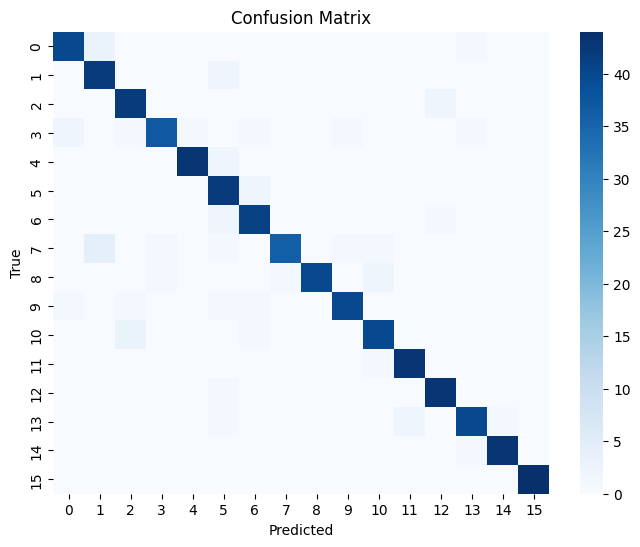

In [18]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred,axis=1)

cm = confusion_matrix(y_test,y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=False,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [19]:
model.save("activity_model.h5")